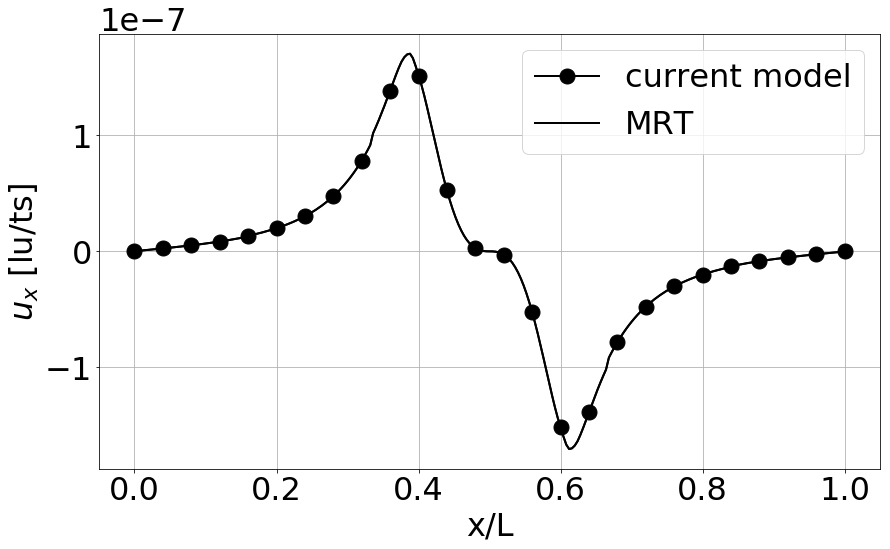

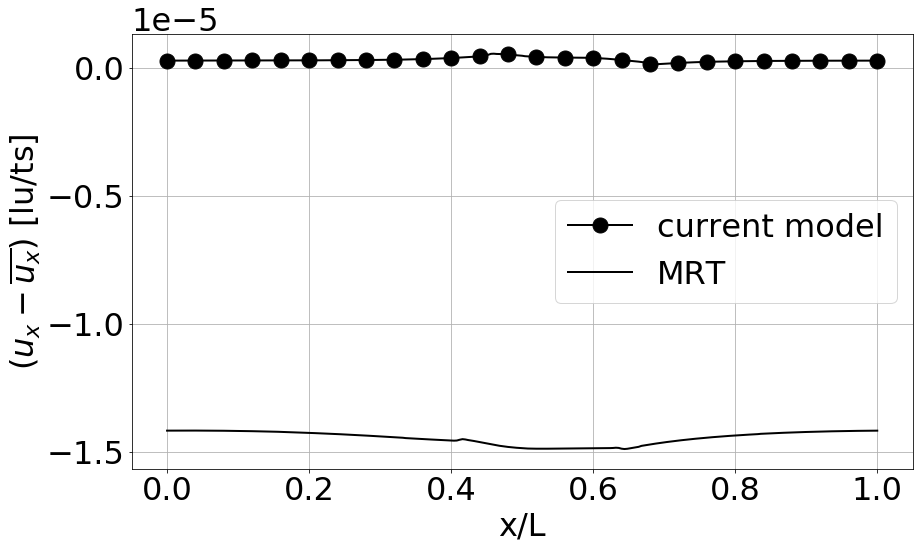

In [4]:

import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import csv
import re
import matplotlib as mpl
# rho_ratio = '1'
# v = '01'
# Ux=0.01

# folder_path = os.path.join("../data_for_plots",
#                            "moving_vs_resting_bubble",
#                            "line_data_rho%s_v%s_circular_Ux%s" % (rho_ratio, v, re.sub('[.]', '', str(Ux))[:]))
# print(folder_path)

rho_ratio = '1'
v = '01'
U='0.01'
Uf=float(U)
Ustr=re.sub("\.", '', U)
folder_path = os.path.join("~/DATA_FOR_PLOTS",
                           "moving_vs_resting_bubble",
                           f"rho{rho_ratio}_v{v}_circular_U{Ustr}",
                           "line_data")

domain_size = 256
frame_n = 999  # last time-frame

frame_cm_resting = pd.read_csv(os.path.join(folder_path, "cm_resting.%d.csv" % frame_n), delimiter=",")
frame_mrt_resting = pd.read_csv(os.path.join(folder_path, "mrt_resting.%d.csv" % frame_n), delimiter=",")
frame_cm_moving = pd.read_csv(os.path.join(folder_path, "cm_moving.%d.csv" % frame_n), delimiter=",")
frame_mrt_moving = pd.read_csv(os.path.join(folder_path, "mrt_moving.%d.csv" % frame_n), delimiter=",")
    
u_cm = np.sqrt(frame_cm_resting['U:0']*frame_cm_resting['U:0']+frame_cm_resting['U:1']*frame_cm_resting['U:1'])
u_mrt = np.sqrt(frame_mrt_resting['U:0']*frame_mrt_resting['U:0']+frame_mrt_resting['U:1']*frame_mrt_resting['U:1'])



# make plot
def make_plot(x1, y1, x2, y2, fig_name, y_label):
    plt.rcParams.update({'font.size': 32})
    plt.figure(figsize=(14, 8))
    # The basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
    
    def smooth(x):
#         x = abs(x)
        return x[0:len(x):4]
        
    plt.plot(smooth(x1), smooth(y1), color="black", marker="o", markevery=10,  markersize=15, linestyle="-", linewidth=2, label='current model')
    plt.plot(smooth(x2), smooth(y2), color="black", marker="", linestyle="-", linewidth=2, label='MRT')
#     plt.yscale('log')
    axes = plt.gca()
    # axes.set_xlim([xmin,xmax])
#     axes.set_ylim([-3E-7, 3E-7])
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    plt.xlabel(r'x/L')
    plt.ylabel(y_label)
    plt.grid(True)
    plt.legend()
    
    fig = plt.gcf()  # get current figure
    fig.savefig(fig_name)#, bbox_inches='tight')
    plt.show()
    plt.close(fig)    # close the figure

make_plot(x1=frame_cm_resting['arc_length']/domain_size, y1=frame_cm_resting['U:0'],
          x2=frame_mrt_resting['arc_length']/domain_size, y2=frame_mrt_resting['U:0'],
          fig_name=f'spurious_currents_CM_vs_MRT_rho{rho_ratio}_v{v}_U{Ustr}_resting_frame.pdf',
          y_label=r'$u_{x}$ [lu/ts]'
         )
    
make_plot(x1=frame_cm_moving['arc_length']/domain_size, y1=frame_cm_moving['U:0']-Uf,
      x2=frame_mrt_moving['arc_length']/domain_size, y2=frame_mrt_moving['U:0']-Uf,
      fig_name=f'spurious_currents_CM_vs_MRT_rho{rho_ratio}_v{v}_U{Ustr}_moving_frame.pdf',
      y_label=r'$(u_{x} - \overline{u_x})$ [lu/ts]'
     )
    

<Figure size 432x288 with 0 Axes>

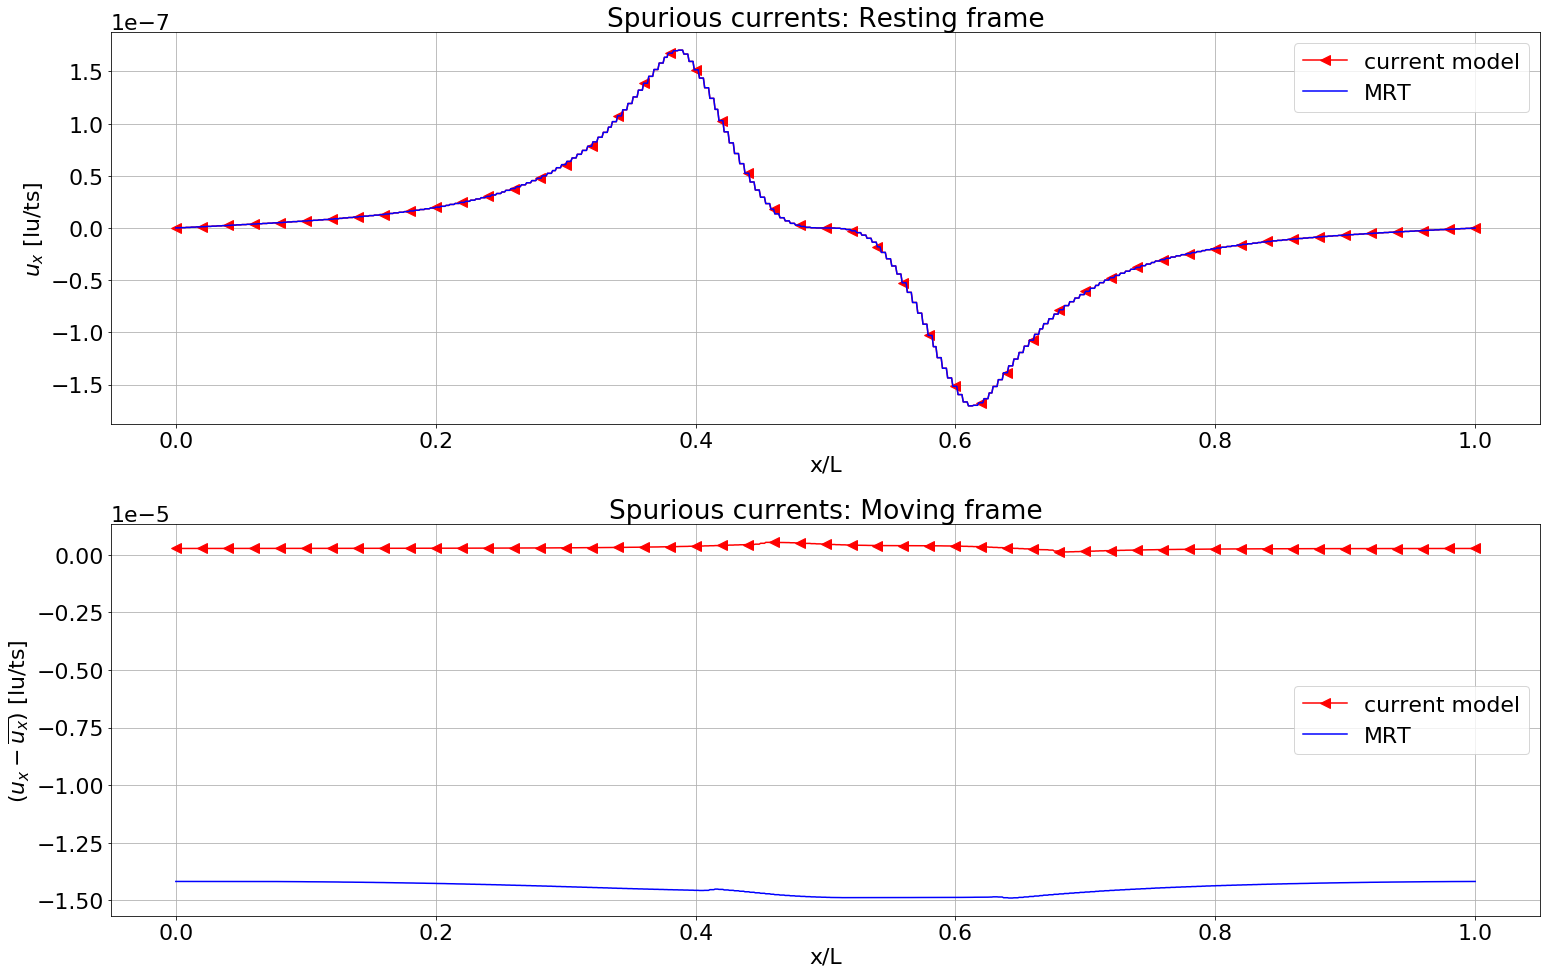

In [4]:
# two plot in one figure

# make plot
plt.figure(1)
plt.figure(figsize=(22, 14))
plt.rcParams.update({'font.size': 22})

# frame_n = 1
# plt.plot(frames_cm_moving[frame_n]['arc_length'], frames_cm_moving[frame_n]['PhaseField'], color="green", marker="", linestyle="-.",  label='cm_test')
# plt.plot(frames_mrt_moving[frame_n]['arc_length'], frames_mrt_moving[frame_n]['PhaseField'], color="red", marker="", linestyle="-", label='mrt_test')

plt.subplot(211)
plt.title('Spurious currents: Resting frame')

# The basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
plt.plot(frame_cm_resting['arc_length']/domain_size, frame_cm_resting['U:0'], color="red", marker="<", markevery=20,  markersize=10, linestyle="-", label='current model')
plt.plot(frame_mrt_resting['arc_length']/domain_size, frame_mrt_resting['U:0'], color="blue", marker="", linestyle="-", label='MRT')

axes = plt.gca()
# axes.set_xlim([xmin,xmax])
# axes.set_ylim([-3E-7, 3E-7])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.xlabel(r'x/L')
plt.ylabel(r'$u_{x}$ [lu/ts]')
plt.grid(True)
plt.legend()

plt.subplot(212)
plt.title(r'Spurious currents: Moving frame')
Uf=float(U)
plt.plot(frame_cm_moving['arc_length']/domain_size, frame_cm_moving['U:0']-Uf, color="red", marker="<", markevery=20,  markersize=10, linestyle="-", label='current model')
plt.plot(frame_mrt_moving['arc_length']/domain_size, frame_mrt_moving['U:0']-Uf, color="blue", marker="", linestyle="-", label='MRT')

# plt.plot(line_size, theoretical, color="black", marker="x", linestyle="", label='theoretical')
axes = plt.gca()
# axes.set_xlim([xmin,xmax])
# axes.set_ylim([-1E-5, 1E-5])
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.xlabel(r'x/L')
plt.ylabel(r'$(u_{x} - \overline{u_x})$ [lu/ts]')
plt.grid(True)
plt.legend()

fig = plt.gcf()  # get current figure
plt.tight_layout()
fig.savefig('spurious_currents_CM_vs_MRT_rho{rho_ratio}_v{v}_U{U}.png' )
plt.show()


In [24]:
x=frame_mrt_moving['U:0']-float(U)
x[100]

-1.419514187000169e-05

In [25]:
float(U)

0.01

In [20]:
re.sub("\.", '', U)

'001'